# Ejercicio Práctico: Clustering (Tabular Playground Series)

**Objetivo:** Agrupar datos utilizando técnicas de aprendizaje no supervisado.
**Pasos principales:**
1. Análisis exploratorio y limpieza.
2. Selección de características (Correlación).
3. Preprocesamiento (Escalado y PCA).
4. Modelado (K-Means) y selección de K óptimo.
5. Visualización y generación de resultados.

## 1. Carga de Datos
Cargamos los ficheros `data.csv` y `sample_submission.csv`. Mostramos las dimensiones iniciales.

In [2]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Configuración de gráficos
plt.style.use('ggplot')
%matplotlib inline

# 1. y 2. Cargar los datos (Asumiendo que están en la misma carpeta)
df = pd.read_csv('data.csv')
sample_submission = pd.read_csv('sample_submission.csv')

print("Datos cargados correctamente.")
print(f"Dimensiones del dataset: {df.shape}")

Datos cargados correctamente.
Dimensiones del dataset: (98000, 30)


## 2. Análisis Descriptivo y Limpieza
Realizamos un resumen estadístico, comprobamos tipos de datos y gestionamos valores nulos.
* Se eliminan filas con nulos si existen.
* Se separa la columna `id`, ya que no aporta información para el agrupamiento.

In [3]:
# 3. Descriptivo del fichero
print("--- Información General ---")
print(df.info())

print("\n--- Estadísticas Descriptivas ---")
display(df.describe())

# Conteo de valores nulos
null_count = df.isnull().sum().sum()
print(f"\nNúmero total de valores nulos: {null_count}")

# Eliminar filas con nulos (si existen)
if null_count > 0:
    df = df.dropna()
    print("Filas con nulos eliminadas.")
else:
    print("No hay valores nulos para eliminar.")

# IMPORTANTE: Guardamos la columna ID para el final y la quitamos del set de entrenamiento
# ya que el ID no aporta información para agrupar (clusterizar).
if 'id' in df.columns:
    ids = df['id']
    df_train = df.drop('id', axis=1)
else:
    # Si la columna se llama diferente (ej. 'Id'), ajusta aquí
    ids = df.index
    df_train = df.copy()

--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98000 entries, 0 to 97999
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      98000 non-null  int64  
 1   f_00    98000 non-null  float64
 2   f_01    98000 non-null  float64
 3   f_02    98000 non-null  float64
 4   f_03    98000 non-null  float64
 5   f_04    98000 non-null  float64
 6   f_05    98000 non-null  float64
 7   f_06    98000 non-null  float64
 8   f_07    98000 non-null  int64  
 9   f_08    98000 non-null  int64  
 10  f_09    98000 non-null  int64  
 11  f_10    98000 non-null  int64  
 12  f_11    98000 non-null  int64  
 13  f_12    98000 non-null  int64  
 14  f_13    98000 non-null  int64  
 15  f_14    98000 non-null  float64
 16  f_15    98000 non-null  float64
 17  f_16    98000 non-null  float64
 18  f_17    98000 non-null  float64
 19  f_18    98000 non-null  float64
 20  f_19    98000 non-null  float64
 21  f_20   

,id,f_00,f_01,f_02,f_03,f_04,f_05,f_06,f_07,f_08,...,f_19,f_20,f_21,f_22,f_23,f_24,f_25,f_26,f_27,f_28
count,98000.000000,98000.000000,98000.000000,98000.000000,98000.000000,98000.000000,98000.000000,98000.000000,98000.000000,98000.000000,...,98000.000000,98000.000000,98000.000000,98000.000000,98000.000000,98000.000000,98000.000000,98000.000000,98000.000000,98000.000000
mean,48999.500000,0.001220,0.005580,-0.001042,-0.000700,-0.003522,-0.001612,-0.003042,5.545918,6.763061,...,-0.004513,-0.000515,-0.001670,-0.038752,-0.220002,0.166434,-0.064309,-0.062540,0.098472,-0.230910
std,28290.307527,1.002801,1.000742,1.001373,1.000422,1.003061,1.000532,0.997434,3.691840,4.152348,...,1.004372,1.002962,0.999703,1.477858,1.494836,1.543014,1.576086,1.428055,1.305407,1.528476
min,0.000000,-4.732235,-4.202795,-4.377021,-4.010826,-4.535903,-4.300767,-4.894525,0.000000,0.000000,...,-4.894525,-4.732235,-4.438130,-6.873999,-8.234305,-7.792363,-6.593842,-7.375719,-7.335556,-6.954151
25%,24499.750000,-0.675226,-0.670985,-0.672779,-0.672540,-0.682510,-0.675066,-0.680421,3.000000,4.000000,...,-0.678773,-0.679777,-0.675147,-1.022964,-1.203204,-0.903385,-1.128966,-0.975680,-0.746489,-1.262606
50%,48999.500000,0.002022,0.006650,-0.000324,-0.003185,-0.003307,0.001024,-0.002053,5.000000,6.000000,...,-0.000587,-0.000806,0.000819,-0.056687,-0.219046,0.167074,-0.099221,-0.070852,0.082230,-0.271319
75%,73499.250000,0.677271,0.677746,0.677086,0.672097,0.677589,0.673344,0.668112,8.000000,9.000000,...,0.672149,0.675437,0.676881,0.930158,0.764690,1.217432,0.987684,0.843212,0.925306,0.770516
max,97999.000000,4.490521,4.324974,4.560247,4.399373,4.050549,4.710316,3.998595,32.000000,30.000000,...,4.560247,4.399373,4.135419,6.517721,6.054831,7.527271,7.544731,7.005608,7.205971,6.977150



Número total de valores nulos: 0
No hay valores nulos para eliminar.


## 3. Análisis de Correlaciones
Calculamos la matriz de correlación para identificar variables redundantes.
* **Criterio:** Si dos variables tienen una correlación absoluta > 0.95 (cercana a 1 o -1), eliminamos una de ellas para evitar ruido en el modelo.

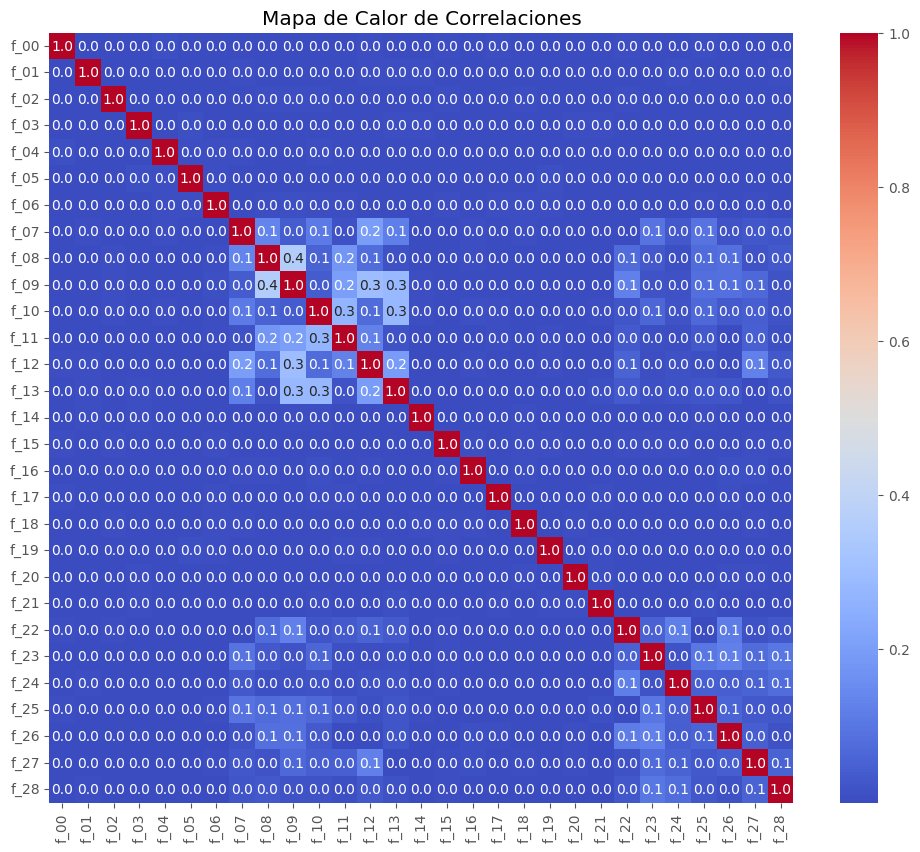

Columnas a eliminar por alta correlación: []
Dimensiones después de eliminar correlaciones altas: (98000, 29)


In [4]:
# 4. Analizar correlaciones
corr_matrix = df_train.corr().abs()

# Mostrar mapa de calor (opcional, para visualizar)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".1f")
plt.title('Mapa de Calor de Correlaciones')
plt.show()

# Identificar columnas con alta correlación (umbral > 0.95)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"Columnas a eliminar por alta correlación: {to_drop}")

# Eliminar las columnas
df_train = df_train.drop(columns=to_drop)
print(f"Dimensiones después de eliminar correlaciones altas: {df_train.shape}")

## 4. Escalado de Datos
Los algoritmos de clustering basados en distancia (como K-Means) son sensibles a la magnitud de las variables. Utilizamos `StandardScaler` para normalizar los datos (media 0, desviación estándar 1).

In [5]:
# 5. Escalar los datos
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_train)

# Convertimos de nuevo a DataFrame para mantener el orden (opcional pero útil)
df_scaled = pd.DataFrame(df_scaled, columns=df_train.columns)
print("Datos escalados correctamente.")

Datos escalados correctamente.


## 5. PCA (Análisis de Componentes Principales)
Reducimos la dimensionalidad del dataset para simplificar el cálculo y eliminar ruido, manteniendo la mayor parte de la varianza explicada.

In [6]:
# 6. Utilizar PCA
# Vamos a probar con un número alto primero para ver la varianza explicada
pca_test = PCA(n_components=0.95) # Mantiene el 95% de la varianza
pca_test.fit(df_scaled)

n_components = pca_test.n_components_
print(f"Número de componentes necesarios para explicar el 95% de varianza: {n_components}")

# Aplicamos la transformación definitiva
pca = PCA(n_components=n_components)
df_pca = pca.fit_transform(df_scaled)

print(f"Shape después de PCA: {df_pca.shape}")

Número de componentes necesarios para explicar el 95% de varianza: 27
Shape después de PCA: (98000, 27)


## 6. Selección del número óptimo de clusters (K)
Utilizamos el **Método del Codo (Elbow Method)** calculando la inercia para diferentes valores de K. Buscamos el punto donde la curva se aplana drásticamente.

Calculando inercia para diferentes k...


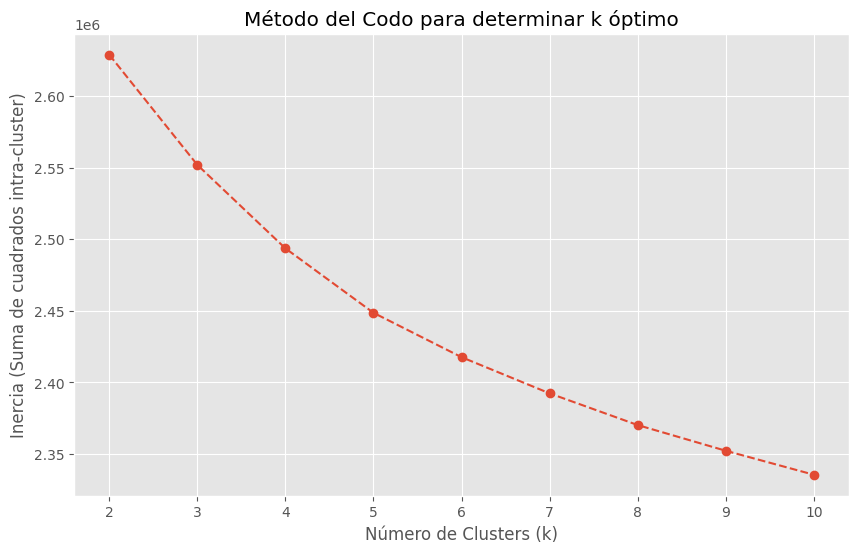

In [7]:
# 7. Buscar una K óptima (Método del Codo)
# Probamos k desde 2 hasta 10 (puedes aumentar el rango si quieres)
inertia = []
K_range = range(2, 11)

print("Calculando inercia para diferentes k...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca)
    inertia.append(kmeans.inertia_)

# Graficar el Codo
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia (Suma de cuadrados intra-cluster)')
plt.title('Método del Codo para determinar k óptimo')
plt.show()

## 7. Clustering K-Means y Visualización
Basándonos en el gráfico anterior, seleccionamos el K óptimo y entrenamos el modelo final. Luego, visualizamos los clusters usando las dos primeras componentes principales.

*(Nota: Ajustar la variable `k_optimo` según lo observado en el gráfico del codo)*.

In [8]:
# 8. Aplica K-means
# IMPORTANTE: Cambia 'k_optimo' por el número que viste en el "codo" del gráfico anterior.
k_optimo = 7  # Ejemplo: Pon aquí el número que consideres (ej. 3, 5, 7)

print(f"Entrenando K-Means con k={k_optimo}...")
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(df_pca)

# Añadimos los clusters a nuestros datos originales (opcional, para análisis)
df['Cluster'] = clusters
print("Clustering completado.")

Entrenando K-Means con k=7...
Clustering completado.


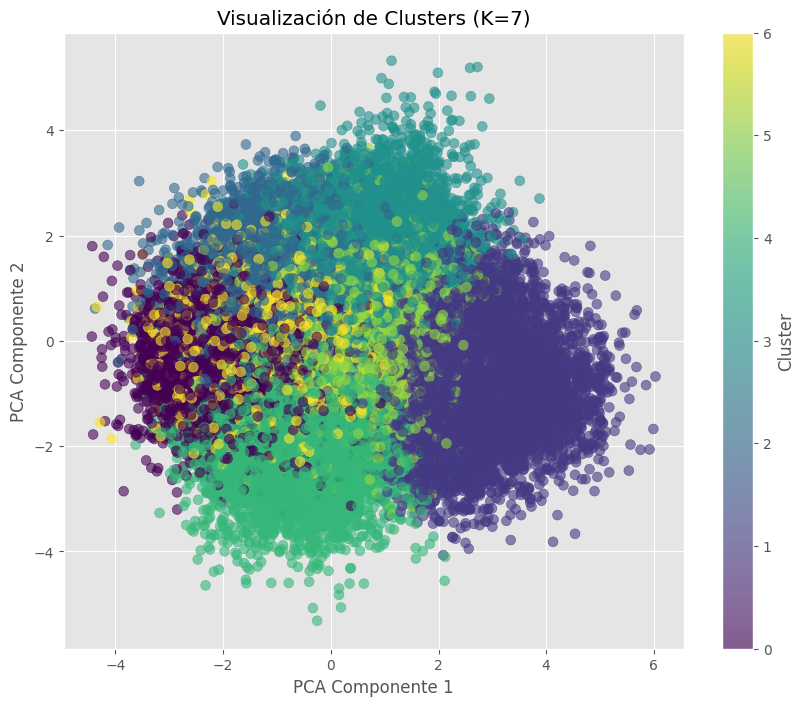

In [9]:
# 9. Plot de los clusters
plt.figure(figsize=(10, 8))

# Usamos las dos primeras componentes principales para el eje X e Y
# c=clusters asigna el color según el grupo
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=clusters, cmap='viridis', s=50, alpha=0.6)

plt.xlabel('PCA Componente 1')
plt.ylabel('PCA Componente 2')
plt.title(f'Visualización de Clusters (K={k_optimo})')
plt.colorbar(label='Cluster')
plt.show()

## 8. Generación del archivo `submission.csv`
Creamos el archivo final con el formato requerido: columnas `Id` y `Predicted` (el cluster asignado).

In [10]:
# 10. Generar el fichero sample_submission.csv
# Debe tener columnas: Id, Predicted

submission = pd.DataFrame()
submission['Id'] = ids # Recuperamos los IDs que guardamos al principio
submission['Predicted'] = clusters

# Verificar formato
print(submission.head())
print(f"Dimensiones de la submission: {submission.shape}")

# Guardar a CSV
submission.to_csv('submission_resultado.csv', index=False)
print("Archivo 'submission_resultado.csv' guardado con éxito.")

   Id  Predicted
0   0          6
1   1          0
2   2          2
3   3          1
4   4          0
Dimensiones de la submission: (98000, 2)
Archivo 'submission_resultado.csv' guardado con éxito.
